# Iris Flower Species Identification
### Iris Dataset | Multi-Class Classification

Identify the species of an Iris flower from petal and sepal measurements,
demonstrating a complete end-to-end supervised classification pipeline.

**Dataset:** Iris.csv — 150 samples | 4 features | 3 species
**Target:** Species (Iris-setosa / Iris-versicolor / Iris-virginica)
**Approach:** CRISP-DM Methodology

## 0. Business Understanding

### Background
Accurate botanical species identification is important for horticulture, conservation,
and ecological research. Misidentifying a species can lead to incorrect planting,
cross-breeding errors, or flawed biodiversity studies. Manual identification by
botanists is time-consuming and requires expertise not always available in the field.

### Business Problem
A botanical research organisation wants to automate the identification of Iris flower
species from simple physical measurements that any field researcher can take with a
ruler. The system should:
- Correctly classify Iris flowers into one of three species based on 4 measurements
- Be fast and reliable enough for field use without requiring a specialist
- Serve as a template for similar species-classification tasks in botany

### ML Objective
Build a **multi-class classification model** that identifies the species of an Iris
flower — Iris-setosa, Iris-versicolor, or Iris-virginica — from four measurements:
sepal length, sepal width, petal length, and petal width (all in centimetres).

### Success Criteria
- **Accuracy** is the primary metric on this balanced, well-structured dataset
- A CV score above 95% is expected — Iris-setosa is linearly separable from the
  other two species, making high accuracy achievable
- Model must correctly handle the Iris-versicolor / Iris-virginica boundary,
  which is the harder classification challenge in this dataset

In [3]:
# Import core libraries for data manipulation, visualisation and numerical operations
# warnings suppressed to keep output clean
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

## 1. Data Loading
Loading the Iris dataset and previewing its basic structure.

In [4]:
# Load the Iris dataset and preview the first few rows to confirm it loaded correctly
df=pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Display column names, data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
# Count unique values per column — useful to spot low-cardinality columns
df.nunique()

Id               150
SepalLengthCm     35
SepalWidthCm      23
PetalLengthCm     43
PetalWidthCm      22
Species            3
dtype: int64

In [8]:
# Summary statistics: mean, std, min, max and quartiles for all numeric features
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
# Count samples per species to check for class imbalance
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 3. Data Cleaning

### 3.1 Duplicate Values
Checking for any repeated rows in the dataset.

In [10]:
# Check for duplicate rows — repeated samples would inflate model performance
df.duplicated().sum()

np.int64(0)

### 3.2 Null Values
Checking for missing values across all columns.

In [11]:
# Check for missing values across all columns
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

### 3.3 Wrong Data Type
Verifying all columns have the correct data types.
Numeric features should be float64, Species should be object.

In [12]:
# Verify data types — numeric features should be float64, Species should be object
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

### 3.4 Outlier Detection & Skewness
Using boxplots to visually detect outliers in all 4 numeric features.
Skewness check — values between -0.5 and 0.5 are approximately normal.

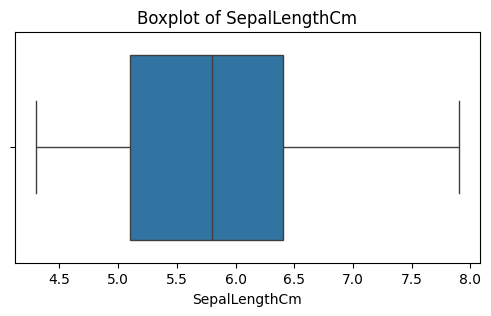

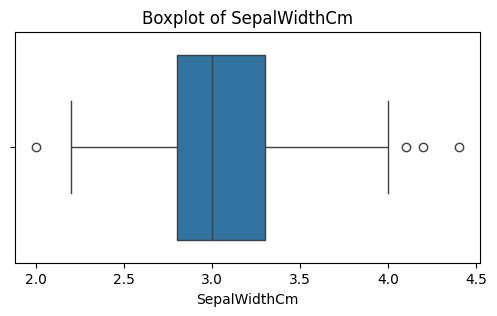

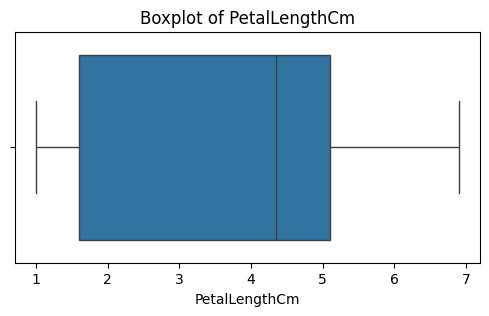

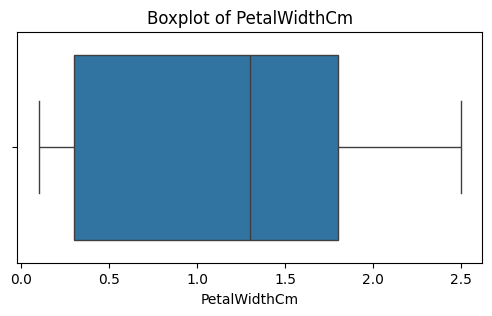

Skewness of numerical features:
SepalLengthCm    0.314911
SepalWidthCm     0.334053
PetalLengthCm   -0.274464
PetalWidthCm    -0.104997
dtype: float64


In [13]:
# Step 4: Outlier Check and Skewness Check

# Numeric feature columns only
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Boxplots for outlier check
for col in feature_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Skewness check
print("Skewness of numerical features:")
print(df[feature_cols].skew())

Q1     : 2.8
Q3     : 3.3
IQR    : 0.5
Lower  : 2.05
Upper  : 4.05

Outliers found: 4
    Id  SepalWidthCm          Species
15  16           4.4      Iris-setosa
32  33           4.1      Iris-setosa
33  34           4.2      Iris-setosa
60  61           2.0  Iris-versicolor


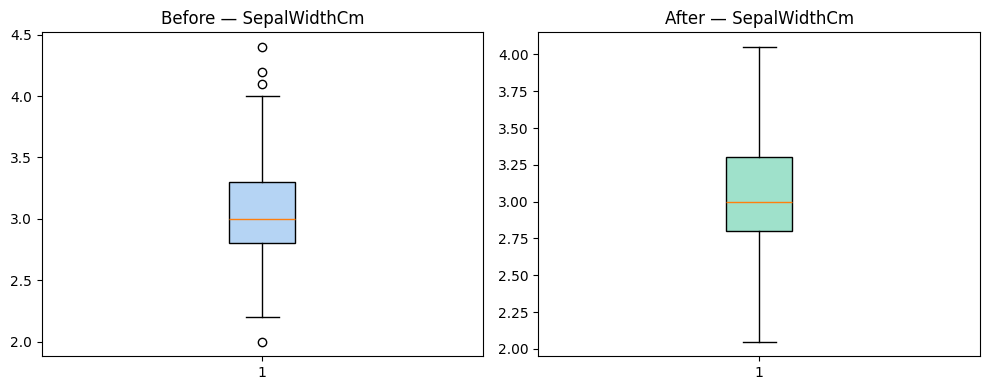


Outliers remaining: 0


In [27]:
import matplotlib.pyplot as plt

col = "SepalWidthCm"

# Check outliers
Q1  = df[col].quantile(0.25)
Q3  = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1     : {Q1}")
print(f"Q3     : {Q3}")
print(f"IQR    : {IQR}")
print(f"Lower  : {lower}")
print(f"Upper  : {upper}")

outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f"\nOutliers found: {len(outliers)}")
print(outliers[["Id", "SepalWidthCm", "Species"]])

# Visualize before fix
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor="#B5D4F4"))
plt.title("Before — SepalWidthCm")

# Fix: cap to IQR bounds
df[col] = df[col].clip(lower=lower, upper=upper)

# Visualize after fix
plt.subplot(1, 2, 2)
plt.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor="#9FE1CB"))
plt.title("After — SepalWidthCm")

plt.tight_layout()
plt.show()

print("\nOutliers remaining:", ((df[col] < lower) | (df[col] > upper)).sum())

## 4. Exploratory Data Analysis (EDA)

### 4.1 Class Distribution
Checking how many samples exist for each species.
A balanced dataset means no resampling is needed.

Species count:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Species percentage:
Species
Iris-setosa        33.0
Iris-versicolor    33.0
Iris-virginica     33.0
Name: proportion, dtype: float64


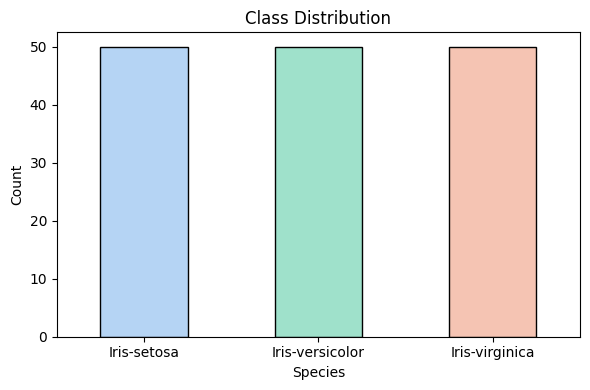

In [29]:
import matplotlib.pyplot as plt

# Count of each species
print("Species count:")
print(df["Species"].value_counts())

print("\nSpecies percentage:")
print(df["Species"].value_counts(normalize=True).round(2) * 100)

# Visualize
plt.figure(figsize=(6, 4))
df["Species"].value_counts().plot(kind="bar", color=["#B5D4F4", "#9FE1CB", "#F5C4B3"], edgecolor="black")
plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


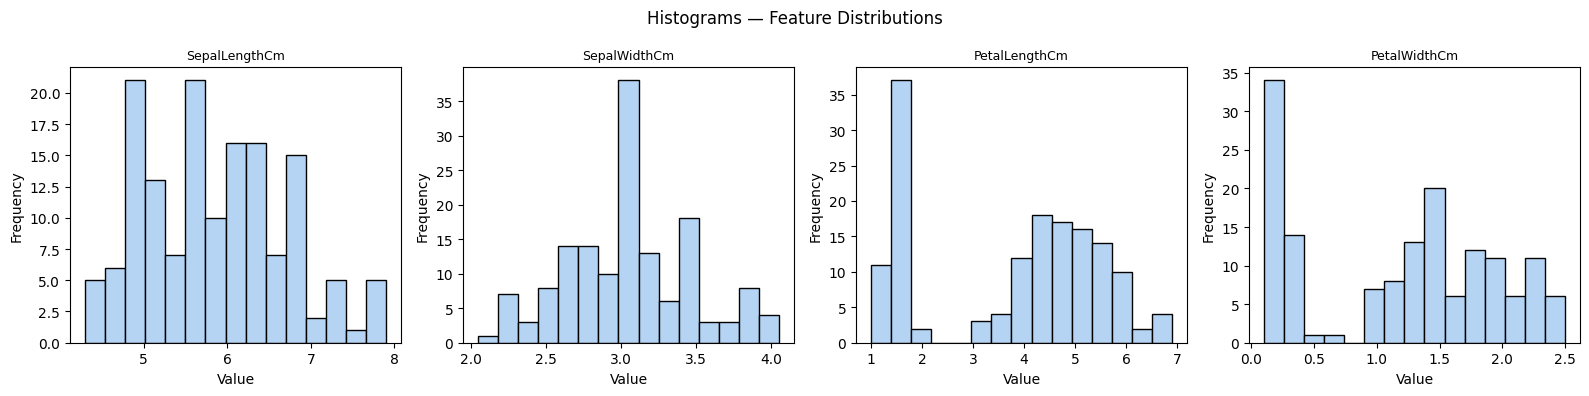

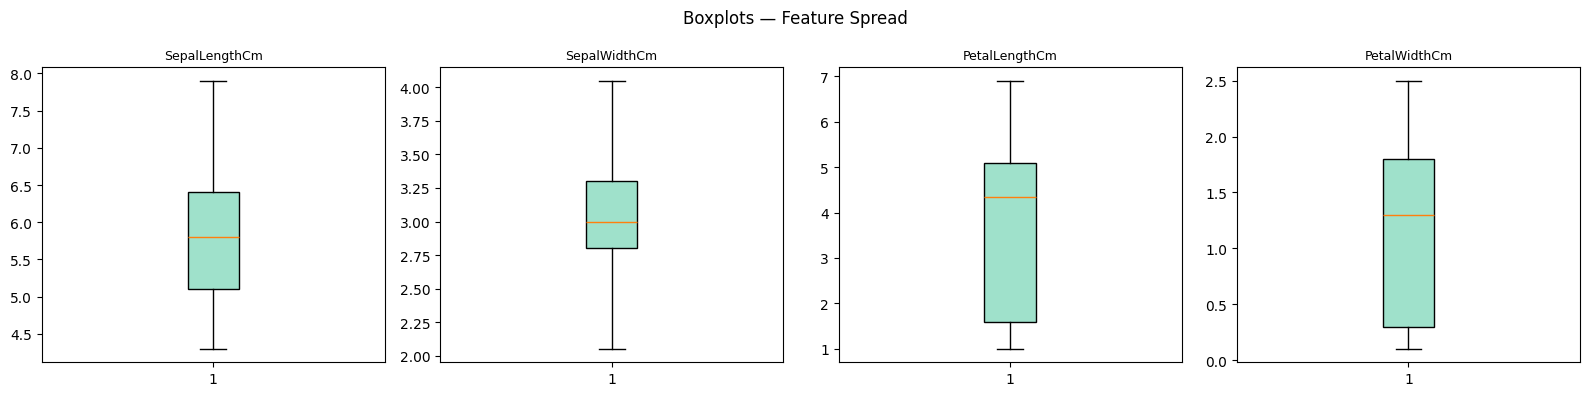

In [31]:
  import matplotlib.pyplot as plt

cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

# Histogram for each feature
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Histograms — Feature Distributions")

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=15, color="#B5D4F4", edgecolor="black")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Boxplot for each feature
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Boxplots — Feature Spread")

for i, col in enumerate(cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor="#9FE1CB"))
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

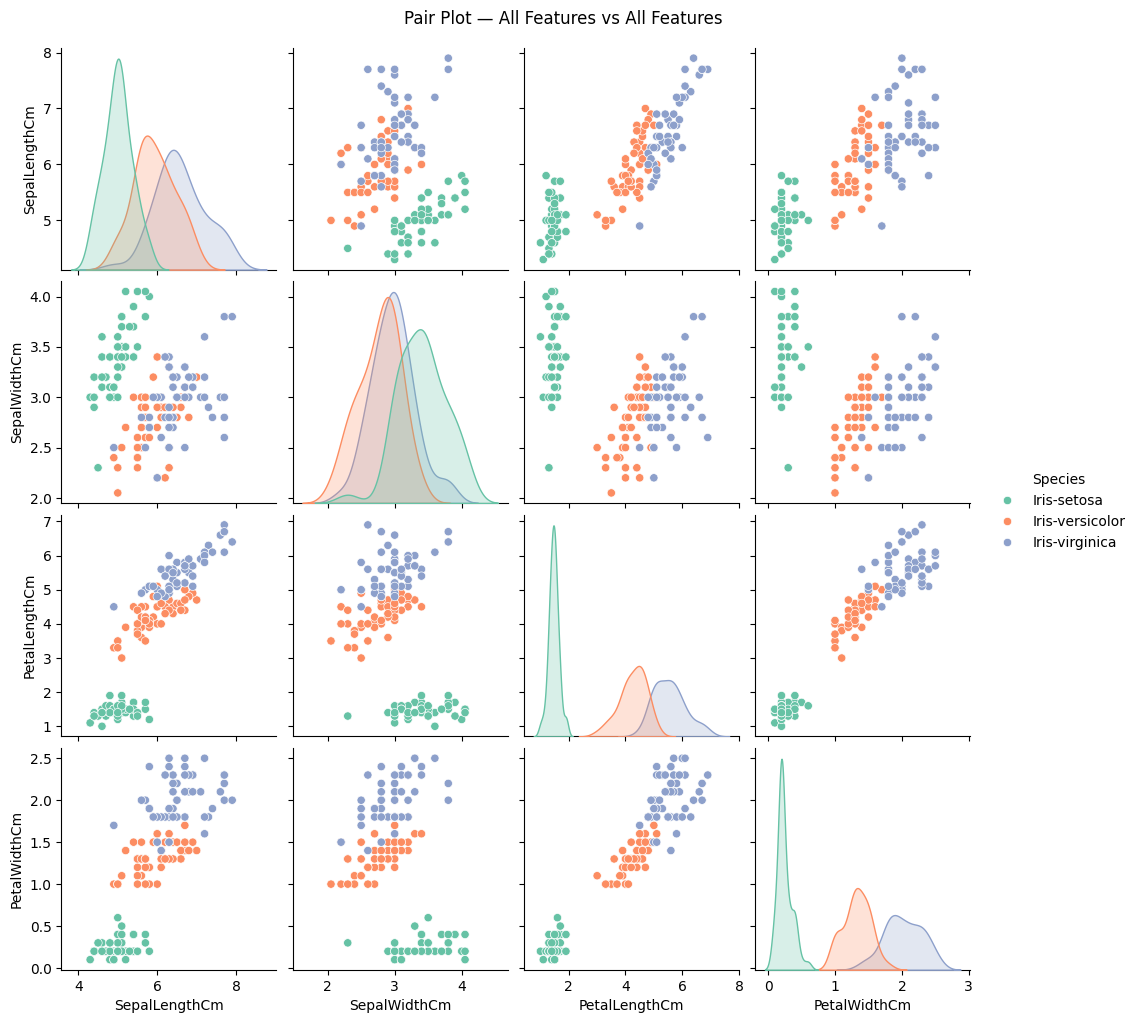

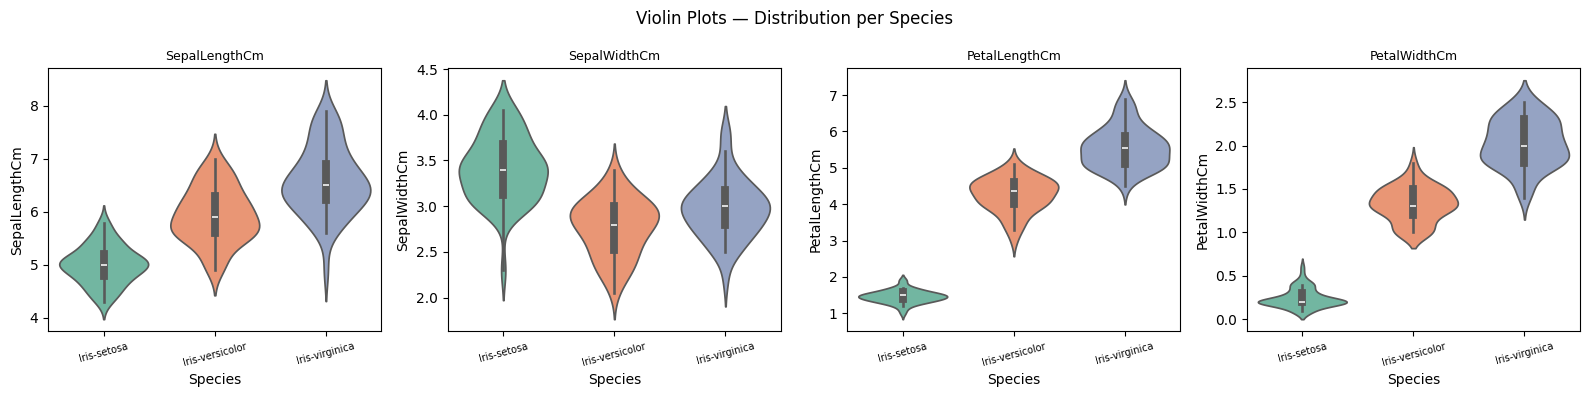

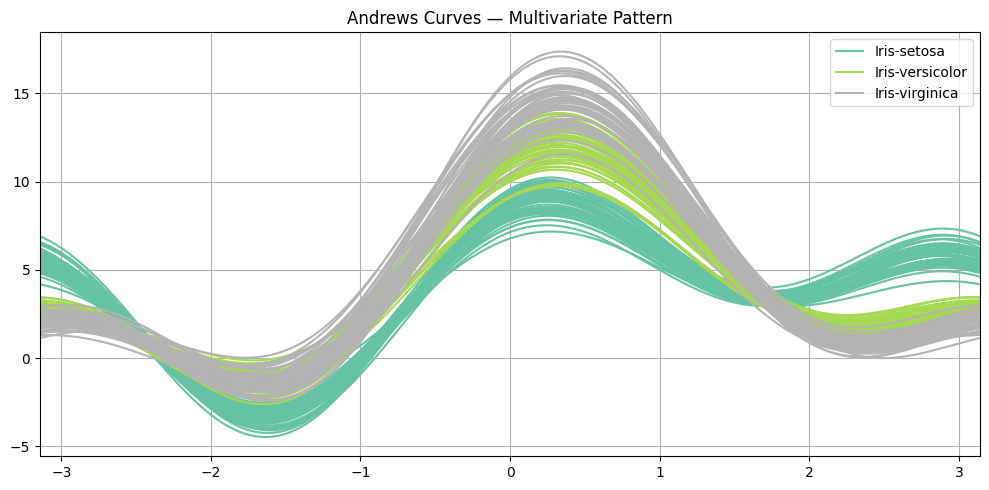

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

# 1. Pair Plot — all features against each other
sns.pairplot(df, hue="Species", vars=cols, palette="Set2")
plt.suptitle("Pair Plot — All Features vs All Features", y=1.02)
plt.show()

# 2. Violin Plot — distribution + spread per species
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Violin Plots — Distribution per Species")

for i, col in enumerate(cols):
    sns.violinplot(data=df, x="Species", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15, fontsize=7)

plt.tight_layout()
plt.show()

# 3. Andrews Curves — multivariate pattern per species
from pandas.plotting import andrews_curves

plt.figure(figsize=(10, 5))
andrews_curves(df[cols + ["Species"]], "Species", colormap="Set2")
plt.title("Andrews Curves — Multivariate Pattern")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

### 5.1 Drop Unnecessary Columns
Dropping the Id column — it is just a row number with no predictive value.

In [35]:
# Id column is just a row number — not useful for the model
print("Before:", df.shape)

df = df.drop(columns=["Id"])

print("After :", df.shape)
print(df.head())

Before: (150, 6)
After : (150, 5)
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


### 5.2 Label Encoding
Converting Species column from string to numeric using LabelEncoder.
ML models only understand numbers — not strings.
Encoding: Iris-setosa=0, Iris-versicolor=1, Iris-virginica=2

In [41]:
# Encode the target column: Iris-setosa=0, Iris-versicolor=1, Iris-virginica=2
# LabelEncoder assigns integer codes alphabetically
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Species"] = le.fit_transform(df["Species"])

print(df["Species"].unique())
print(df.head())

[0 1 2]
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0


### 5.3 Train Test Split
Splitting data into 80% training (120 rows) and 20% testing (30 rows).
random_state=42 ensures the same split every time the notebook is run.

In [43]:
# Separate features (X) from encoded target (y) and split 80/20
# random_state=42 ensures reproducibility
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Species"])
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0      -0.900681      1.065722      -1.341272     -1.312977        0
1      -1.143017     -0.120170      -1.341272     -1.312977        0
2      -1.385353      0.354187      -1.398138     -1.312977        0
3      -1.506521      0.117008      -1.284407     -1.312977        0
4      -1.021849      1.302901      -1.341272     -1.312977        0


### 5.4 Feature Scaling
Applying StandardScaler to all 4 numeric features.
Converts each feature to mean=0 and std=1 so no single feature dominates the model.
fit_transform on X_train only — transform applied to X_test to prevent data leakage.

In [45]:
# Standardise all 4 numeric features to mean=0 and std=1
# Scaling is required before KNN, SVM and Logistic Regression
# fit_transform on X_train only — transform on X_test prevents data leakage
from sklearn.preprocessing import StandardScaler

cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

scaler = StandardScaler()
X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols]  = scaler.transform(X_test[cols])

print("Scaling done!")
print(X_train.head())

X_train: (120, 4)
X_test : (30, 4)
y_train: (120,)
y_test : (30,)


## 6. Modelling
Importing all required classifiers and evaluation metrics.
8 models will be trained and compared using Train Accuracy, CV Score and Test Accuracy.

In [47]:
# Import all classifiers and evaluation utilities needed for the modelling section
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

### 6.1 Logistic Regression
Baseline linear classifier — works well when classes are linearly separable.
Iris-setosa is linearly separable from the other two species making this a strong baseline.

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

# Train accuracy
ypred_train = log_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, ypred_train))

# Cross validation
cv_score = cross_val_score(log_model, X_train, y_train, cv=5, scoring="accuracy").mean()
print("CV Score     :", round(cv_score, 4))

# Test accuracy
ypred_test = log_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, ypred_test))

Train Accuracy: 0.9666666666666667
CV Score     : 0.9583
Test Accuracy: 1.0


### 6.1.1 Evaluation — Logistic Regression
Confusion matrix shows predicted vs actual class counts.
Classification report shows precision, recall and F1 score per class.

In [51]:
# Print confusion matrix and full classification report for the evaluated model
# Report shows precision, recall and F1-score per species
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,ypred_test))

from sklearn.metrics import classification_report
print(classification_report(y_test,ypred_test))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### 6.2 K-Nearest Neighbors (KNN)
Distance based classifier — classifies based on the k closest training samples.
GridSearchCV tunes n_neighbors (1-20) and distance metric p (1=Manhattan, 2=Euclidean).

In [72]:
#Hyperparameter Tuning
estimator = KNeighborsClassifier()
param_grid = {"n_neighbors":list(range(1,20)),"p":[1,2]}
knn_grid = GridSearchCV(estimator, param_grid,scoring="accuracy",cv=5)
knn_grid.fit(X_train,y_train)

#KNN with best Hyperparametres
knn_grid.best_estimator_

,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [74]:
#Modelling
knn_model = knn_grid.best_estimator_
knn_model.fit(X_train,y_train)

#predict And evaluate on Train Data
ypred_train = knn_model.predict(X_train)
print("Train Accuracy:",accuracy_score(y_train,ypred_train))

#cross Validation Score
print("CV score:",cross_val_score(knn_model,X_train,y_train,cv=5,scoring="accuracy").mean())

#predict and evaluate
ypred_test=knn_model.predict(X_test)
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.9583333333333334
CV score: 0.9583333333333334
Test Accuracy: 1.0


### 6.3 Support Vector Machine (SVM)
Finds the optimal hyperplane that best separates the 3 species.
GridSearchCV tunes C (regularization) and kernel type (linear, rbf, sigmoid, poly).

In [77]:
from sklearn.svm import SVC
estimator = SVC(random_state=True)
param_grid={"C":[0.01,0.1,1],"kernel":["linear","rbf","sigmoid","poly"]}
svm_grid=GridSearchCV(estimator,param_grid,scoring="accuracy",cv=5)
svm_grid.fit(X_train,y_train)

#SVM with best Hyperparamters
svm_grid.best_estimator_

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [79]:
#modelling
svm_model = svm_grid.best_estimator_
svm_model.fit(X_train,y_train)

# predict and Evaluate on train data
ypred_train = svm_model.predict(X_train)
print("Train Accuracy:",accuracy_score(y_train,ypred_train))

#cross Validation on Train data
print("CV Score:",cross_val_score(svm_model,X_train,y_train,cv=5,scoring="accuracy").mean())

#predict and Evaluate on test data
ypred_test = svm_model.predict(X_test)
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.9666666666666667
CV Score: 0.95
Test Accuracy: 1.0


### 6.4 Decision Tree Classifier
Tree based model that splits data based on feature thresholds.
First trained without tuning to check default depth — then tuned with GridSearchCV.
max_depth limited to range(1,6) to prevent overfitting on this small dataset.
Feature importance extracted to identify which features matter most.

In [82]:
# Fit a baseline Decision Tree on the training data before hyperparameter tuning
model = DecisionTreeClassifier(random_state=True)
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,True
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [86]:
# Print tree depth to understand model complexity before pruning/tuning
print(model.get_depth())

6


In [88]:
#hyperparameter Tuning
estimator = DecisionTreeClassifier(random_state=True)
param_grid={"criterion":["gini","entropy"],
            "max_depth":list(range(1,6))}
dt_grid = GridSearchCV(estimator,param_grid,scoring="accuracy",cv=5)
dt_grid.fit(X_train,y_train)

dt= dt_grid.best_estimator_
dt

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,True
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 6.4.1 AUC Score — Decision Tree
Using multi_class='ovr' (One vs Rest) since this is a 3-class problem.
predict_proba returns class probabilities for all 3 species.
AUC of 1.0 means perfect class separation.

In [96]:
# Compute multi-class AUC using One-vs-Rest strategy
# predict_proba returns probability scores needed for AUC calculation
from sklearn.metrics import roc_auc_score

y_prob_dt = dt.predict_proba(X_test)

print("AUC Score:", roc_auc_score(y_test, y_prob_dt, multi_class="ovr"))

AUC Score: 1.0


### 6.4.2 Feature Importance — Decision Tree
Extracting features with importance > 0.
Petal features are expected to dominate as they showed the clearest
separation between species in EDA.

In [98]:
#Important features
feats_ab = pd.DataFrame(data=dt.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_dt = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_dt

['PetalLengthCm', 'PetalWidthCm']

### 6.4.3 Retrain Decision Tree with Important Features
Retraining the best Decision Tree on selected important features only.
X_train and X_test already have column names since scaling was done on the DataFrame.

In [100]:
#Selecting train and test data
X_train_dt = X_train[important_features_dt]
X_test_dt = X_test[important_features_dt]

#modelling
dt=dt_grid.best_estimator_
dt.fit(X_train_dt,y_train)

#Evaluation
ypred_train = dt.predict(X_train_dt)
ypred_test = dt.predict(X_test_dt)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(dt,X_train_dt,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.9583333333333334
CV score: 0.9333333333333333
Test Accuracy: 1.0


### 6.5 Random Forest Classifier
Ensemble of decision trees — reduces overfitting compared to a single tree.
GridSearchCV tunes n_estimators (1-20).
Feature importance extracted and model retrained on relevant features only.

In [103]:
#Hyperparameter Tuning
estimator = RandomForestClassifier(random_state=True)

param_grid = {"n_estimators":list(range(1,20))}

rf_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
rf_grid.fit(X_train,y_train)

rf=rf_grid.best_estimator_
rf

,n_estimators,5
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [105]:
#Important features
feats_ab = pd.DataFrame(data=rf.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_rf = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_rf

['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

In [107]:
#Selecting train and test data
X_train_rf = X_train[important_features_rf]
X_test_rf = X_test[important_features_rf]

#modelling
rf=rf_grid.best_estimator_
rf.fit(X_train_rf,y_train)

#Evaluation
ypred_train = rf.predict(X_train_rf)
ypred_test = rf.predict(X_test_rf)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(rf,X_train_rf,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.9916666666666667
CV score: 0.9416666666666667
Test Accuracy: 1.0


### 6.6 AdaBoost Classifier
Boosting ensemble — focuses more on misclassified samples in each iteration.
GridSearchCV tunes n_estimators (1-100).
Feature importance extracted for feature selection.ly.

In [112]:
#Hyperparameter Tuning
estimator = AdaBoostClassifier(random_state=True)
param_grid = {"n_estimators":list(range(1,100))}

ab_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
ab_grid.fit(X_train,y_train)

ab=ab_grid.best_estimator_
ab

,estimator,None
,n_estimators,23
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,True


In [113]:
#Important features
feats_ab = pd.DataFrame(data=ab.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_ab = feats_ab[feats_ab["Importance"]>0].index.tolist()
important_features_ab

['SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

In [116]:
#Selecting train and test data
X_train_ab = X_train[important_features_ab]
X_test_ab = X_test[important_features_ab]

#modelling
ab=ab_grid.best_estimator_
ab.fit(X_train_ab,y_train)

#Evaluation
ypred_train = ab.predict(X_train_ab)
ypred_test = ab.predict(X_test_ab)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(ab,X_train_ab,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.975
CV score: 0.9583333333333334
Test Accuracy: 1.0


### 6.7 Gradient Boosting Classifier
Sequential ensemble that minimizes loss by adding weak learners one at a time.
GridSearchCV tunes n_estimators and learning_rate.

In [119]:
#Hyperparameter Tuning
estimator = GradientBoostingClassifier(random_state=True)
param_grid = {"n_estimators":list(range(1,10)),
             "learning_rate":[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]}

gb_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
gb_grid.fit(X_train,y_train)

gb=gb_grid.best_estimator_
gb

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,1
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [121]:
#Important features
feats_gb = pd.DataFrame(data=gb.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_gb = feats_gb[feats_gb["Importance"]>0].index.tolist()
important_features_gb

['PetalLengthCm', 'PetalWidthCm']

In [123]:
#Selecting train and test data
X_train_gb = X_train[important_features_gb]
X_test_gb = X_test[important_features_gb]

#modelling
gb=gb_grid.best_estimator_
gb.fit(X_train_gb,y_train)

#Evaluation
ypred_train = gb.predict(X_train_gb)
ypred_test = gb.predict(X_test_gb)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(gb,X_train_gb,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.975
CV score: 0.9333333333333333
Test Accuracy: 1.0


### 6.8 XGBoost Classifier
Optimized gradient boosting with regularization to prevent overfitting.
GridSearchCV tunes n_estimators, max_depth, and gamma.

In [128]:
#Hyperparameter Tuning
estimator = XGBClassifier()
param_grid = {"n_estimators":[10,20,40,100],
              "max_depth":[3,4,5],
             "gamma":[0,0.15,0.3,0.5,1]}

xgb_grid = GridSearchCV(estimator,param_grid,scoring = "accuracy",cv=5)
xgb_grid.fit(X_train,y_train)

xgb=xgb_grid.best_estimator_
xgb

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [130]:
#Important features
feats_xgb = pd.DataFrame(data=xgb.feature_importances_,
                        index=X.columns,
                        columns=["Importance"])
important_features_xgb = feats_xgb[feats_xgb["Importance"]>0].index.tolist()
important_features_xgb

['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

In [132]:
#Selecting train and test data
X_train_xgb = X_train[important_features_xgb]
X_test_xgb = X_test[important_features_xgb]

#modelling
xgb=xgb_grid.best_estimator_
xgb.fit(X_train_xgb,y_train)

#Evaluation
ypred_train = xgb.predict(X_train_xgb)
ypred_test = xgb.predict(X_test_xgb)

print("Train Accuracy:",accuracy_score(y_train,ypred_train))
print("CV score:",cross_val_score(xgb,X_train_xgb,y_train,cv=5,scoring="accuracy").mean())
print("Test Accuracy:",accuracy_score(y_test,ypred_test))

Train Accuracy: 0.9833333333333333
CV score: 0.95
Test Accuracy: 1.0


## 7. Prediction on New Flowers
Using the best model (Logistic Regression) to predict species of 3 new unseen flowers.
Same scaler fitted during training is used — never refit on new data.

Species mapping:
- 0 → Iris-setosa
- 1 → Iris-versicolor
- 2 → Iris-virginica

In [134]:
import numpy as np

# New data [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]
new_data = np.array([[5.1, 3.5, 1.4, 0.2],
                     [6.7, 3.0, 5.2, 2.3],
                     [5.8, 2.7, 4.1, 1.0]])

# Scale using same scaler
new_data_scaled = scaler.transform(new_data)

# Predict
predictions = log_model.predict(new_data_scaled)

# Map to species names
species_map = {0: "Iris-setosa", 1: "Iris-versicolor", 2: "Iris-virginica"}

for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: {new_data[i]} → {species_map[pred]}")

Sample 1: [5.1 3.5 1.4 0.2] → Iris-setosa
Sample 2: [6.7 3.  5.2 2.3] → Iris-virginica
Sample 3: [5.8 2.7 4.1 1. ] → Iris-versicolor
